# Minnesota TEFAP Funding

A short notebook with information about where TEFAP funds and foods are distributed in Minnesota.

## CY2025 TEFAP Case Distribution

The data are from a 04/08/26 MN DCYF data request.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
mn_shelves = pd.read_excel("data/DCYF_Data_Request_4_8_26.xlsx", sheet_name=1)
mn_shelves = mn_shelves.drop(index=[499, 500])
mn_shelves = mn_shelves.rename(
    columns={
        "TEFAP Distribution Site Name": "site",
        "TEFAP Cases Distributed 2025": "cases_distributed",
    }
)
len(mn_shelves)

499

In [ ]:
# checking to see if there are any non-integers:
mn_shelves.loc[mn_shelves["cases_distributed"] % 1 != 0, "cases_distributed"].count()

np.int64(0)

In [ ]:
# casting to int
mn_shelves["cases_distributed"] = mn_shelves["cases_distributed"].astype("int")

In [ ]:
# Total TEFAP cases distributed
mn_shelves["cases_distributed"].sum()

np.int64(512608)

In [ ]:
# Top ten largest food shelves
mn_shelves.sort_values("cases_distributed", ascending=False).head(10)

,site,cases_distributed,county
276,Manna Market Substance,24327,Hennepin
73,Channel One Food Shelf,15856,Olmsted
472,"VEAP, Inc.",10794,Hennepin
342,Open Cupboard,10163,Washington
205,Hope For The Community,9891,Anoka
231,Individuals Second Harvest Food Shelf,9500,NaN
429,The Corner Shelf,8088,NaN
471,Valley Outreach,7668,NaN
246,Keystone Community Food Center,7500,NaN
91,Community Pathways of Steele County-Owatonna,7124,NaN


In [ ]:
mn_shelves.loc[mn_shelves["site"] == "Manna Market Substance", "county"] = "Hennepin"
mn_shelves.loc[mn_shelves["site"] == "Channel One Food Shelf", "county"] = "Olmsted"
mn_shelves.loc[mn_shelves["site"] == "VEAP, Inc.", "county"] = "Hennepin"
mn_shelves.loc[mn_shelves["site"] == "Open Cupboard", "county"] = "Washington"
mn_shelves.loc[mn_shelves["site"] == "Hope For The Community", "county"] = "Anoka"

In [50]:
sns.color_palette("rocket")

[(0.20973515, 0.09747934, 0.24238489),
 (0.43860848, 0.12177004, 0.34119475),
 (0.67824099, 0.09192342, 0.3504148),
 (0.8833417, 0.19830556, 0.26014181),
 (0.95381595, 0.46373781, 0.31769923),
 (0.96516917, 0.70776351, 0.5606593)]

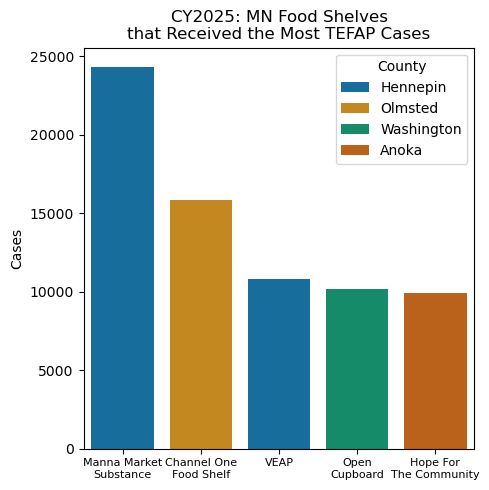

In [ ]:
top5 = mn_shelves.sort_values("cases_distributed", ascending=False).head(5)
top5.loc[top5["site"] == "Manna Market Substance", "site"] = "Manna Market\nSubstance"
top5.loc[top5["site"] == "Channel One Food Shelf", "site"] = "Channel One\nFood Shelf"
top5.loc[top5["site"] == "VEAP, Inc.", "site"] = "VEAP"
top5.loc[top5["site"] == "Open Cupboard", "site"] = "Open\nCupboard"
top5.loc[top5["site"] == "Hope For The Community", "site"] = "Hope For\nThe Community"

fig, ax = plt.subplots(figsize=(5, 5))

sns.barplot(
    data=top5,
    x="site",
    y="cases_distributed",
    hue="county",
    palette="colorblind",
    ax=ax,
)

ax.tick_params(axis="x", labelsize=8)
ax.set_title("CY2025: MN Food Shelves\nthat Received the Most TEFAP Cases")
ax.set_xlabel("")
ax.set_ylabel("Cases")
plt.legend(title="County")
plt.tight_layout()
plt.show()